### 4.7 Credit Stress & Illustrative ECL

$$PD_{stressed} = \operatorname{clip}\!\big(PD_{base} + s\cdot\Delta u_{cum}/100,\ PD_{base},\ 1.0\big)$$

$$ECL = \dfrac{PD_{stressed}\times LGD\times EAD}{(1+r)^{0.5}}$$

$$ECL_{weighted} = \sum_{scenario} w_{scenario}\,ECL_{scenario}$$

NAB's own disclosed FY2025 Pillar 3 PD/LGD/EAD {cite}`nab2025pillar3`, stressed with
unemployment-sensitivity coefficients from a published RBA research paper
{cite}`garvin2022macrofinancial` (0.4pp personal loans / 0.6pp mortgages per point of
cumulative unemployment change), mid-year discounted at RBA's published lending rates,
and combined with NAB's own 55/42.5/2.5 base/downside/upside scenario weights
{cite}`nab2025annualreport`. **This is 12-month, Stage-1-only and is not a lower bound on
NAB's real provision** — no Stage 2/3 staging logic exists.

*Source: `src/models/credit_stress.py`, served at `GET /credit-risk/stress-test`*

#### Explained, step by step

- **Stressing the default probability.** Start from NAB's own disclosed baseline probability of default, $PD_{base}$. $\Delta u_{cum}$ is the cumulative *change* in the unemployment rate under a given macro scenario (e.g. +1.5 percentage points cumulative under "downside"), divided by 100 to convert percentage points into a plain fraction. $s$ is a sensitivity coefficient — how much default risk moves per unit of extra unemployment — taken from generic RBA guidance rather than fitted from NAB's own book. $\operatorname{clip}(x, PD_{base}, 1.0)$ enforces two sanity limits: the stressed PD can never fall *below* the baseline (a stress scenario shouldn't look safer than baseline) and can never exceed 100% (a probability can't exceed 1).
- **Expected Credit Loss (ECL).** The standard actuarial formula: probability something defaults ($PD_{stressed}$), times how much would actually be lost if it did ($LGD$, loss given default, as a fraction of exposure), times how much exposure is outstanding ($EAD$, exposure at default) — gives the expected dollar loss. Dividing by $(1+r)^{0.5}$ discounts that loss back to present value assuming it lands, on average, half a year into a 12-month window (the "mid-year" convention), using the RBA's own published lending rate $r$.
- **Blending scenarios.** Rather than reporting one scenario's ECL alone, $ECL_{weighted}$ is a probability-weighted average across upside, base, and downside scenarios, using NAB's own disclosed likelihood weights for each (55% base / 42.5% downside / 2.5% upside) — turning three separate what-if numbers into a single expected-value estimate reflecting how likely each scenario is actually thought to be. Carried over from the app verbatim: this is 12-month, Stage-1-only, and explicitly **not** a lower bound on NAB's real provisioning.

#### Where the scenario deltas come from

Before the ECL outcomes below, here's what actually generates the three $\Delta u_{cum}$
values in the formula above: [§4.4](44_svar)'s System B, forecasting its own
`unemployment_rate` variable forward from the 2025Q4 origin, block-bootstrap simulated
(the same `simulate_paths_from_fit` machinery used throughout this section) and read off
at each horizon.

The stress test below uses horizon 4 (2026Q4, one year ahead) for its downside/base/upside
`p90`/`p50`/`p10` scenario deltas — the point marked on the chart.

*Source: `src/models/svar.py::forecast_cumulative_unemployment_change_quantiles`, called
once per horizon 1-8 for this chart; only horizon 4 feeds the live
`GET /credit-risk/stress-test` endpoint and the table below.*

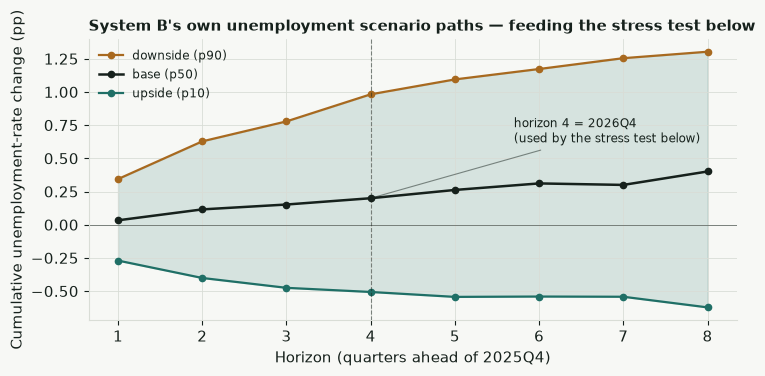

,"downside Δu_cum (pp), used below","base Δu_cum (pp), used below","upside Δu_cum (pp), used below"
horizon,,,
4,0.9821,0.1996,-0.5064


In [6]:
from src.models import svar

STRESS_TEST_HORIZON = 4

records = []
for h in range(1, 9):
    deltas, origin = svar.forecast_cumulative_unemployment_change_quantiles(
        horizon=h, quantiles=(0.9, 0.5, 0.1)
    )
    records.append({"horizon": h, "downside": deltas[0], "base": deltas[1], "upside": deltas[2]})
path = pd.DataFrame(records).set_index("horizon")

fig, ax = plt.subplots(figsize=(7.6, 3.8))
ax.axhline(0, color=INK, linewidth=0.7, alpha=0.5)
ax.fill_between(path.index, path["upside"], path["downside"], color=ACCENT, alpha=0.15)
ax.plot(path.index, path["downside"], color=HIGHLIGHT, linewidth=1.6, marker="o", markersize=4.5,
        label="downside (p90)")
ax.plot(path.index, path["base"], color=INK, linewidth=1.8, marker="o", markersize=4.5, label="base (p50)")
ax.plot(path.index, path["upside"], color=ACCENT, linewidth=1.6, marker="o", markersize=4.5, label="upside (p10)")
ax.axvline(STRESS_TEST_HORIZON, color=INK, linewidth=0.8, linestyle="--", alpha=0.5)
ax.annotate(
    "horizon 4 = 2026Q4\n(used by the stress test below)",
    xy=(STRESS_TEST_HORIZON, path.loc[STRESS_TEST_HORIZON, "base"]),
    xytext=(5.7, 0.62),
    fontsize=8.5, color=INK, ha="left",
    arrowprops=dict(arrowstyle="-", color=INK, alpha=0.5, linewidth=0.8),
)
ax.set_xlabel("Horizon (quarters ahead of 2025Q4)")
ax.set_ylabel("Cumulative unemployment-rate change (pp)")
ax.set_title("System B's own unemployment scenario paths — feeding the stress test below",
             loc="left", fontsize=11, fontweight="bold")
ax.legend(frameon=False, fontsize=8.5, ncol=1, loc="upper left")
fig.tight_layout()
plt.show()

path.loc[[STRESS_TEST_HORIZON]].round(4).rename_axis("horizon").rename(
    columns=lambda c: f"{c} Δu_cum (pp), used below"
)


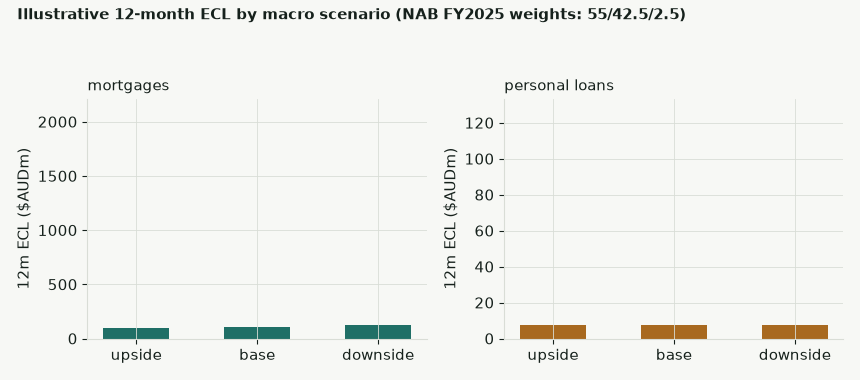

,segment,probability_weighted_ecl_aud_m
0,personal_loans,104.612271
3,mortgages,1588.636471


In [47]:
credit = pd.read_csv(PROJECT_ROOT / "reports/tableau/credit_stress.csv")
order = ["upside", "base", "downside"]
segs = ["mortgages", "personal_loans"]
scol = {"mortgages": ACCENT, "personal_loans": HIGHLIGHT}

fig, axes = plt.subplots(1, 2, figsize=(8.6, 3.8))
bars = {}
for ax, seg in zip(axes, segs):
    sub = credit[credit["segment"] == seg].set_index("scenario").loc[order]
    ax.set_ylim(0, sub["ecl_aud_m"].max() * 1.25)
    ax.set_title(seg.replace("_", " "), fontsize=11, loc="left")
    ax.set_ylabel("12m ECL ($AUDm)")
    bars[seg] = (ax.bar(order, [0, 0, 0], color=scol[seg], width=0.55), sub["ecl_aud_m"].to_numpy())
fig.suptitle("Illustrative 12-month ECL by macro scenario (NAB FY2025 weights: 55/42.5/2.5)",
             fontsize=11, fontweight="bold", x=0.02, ha="left")
fig.tight_layout(rect=(0, 0, 1, 0.92))

N = 20
def update_credit(i):
    t = min(1.0, (i + 1) / (N - 6))
    artists = []
    for seg in segs:
        bar, targets = bars[seg]
        for rect, target in zip(bar, targets):
            rect.set_height(target * t)
        artists.extend(bar)
    return artists

anim_credit = animation.FuncAnimation(fig, update_credit, frames=N, interval=80, blit=False)
gif_path2 = PROJECT_ROOT / "notebooks/assets/credit_stress_animation.gif"
anim_credit.save(gif_path2, writer=animation.PillowWriter(fps=12))
plt.close(fig)
display(Image(filename=str(gif_path2)))

weighted = credit.drop_duplicates("segment")[["segment", "ecl_aud_m_12m_probability_weighted"]]
weighted.columns = ["segment", "probability_weighted_ecl_aud_m"]
weighted

#### References

```{bibliography}
:filter: docname in docnames
```